# 🤖 Modelagem — Previsão de Alagamentos em São Paulo
## TCC · Henrique Nascimento Santos

**Dataset:** CEMADEN (95 estações) + ERA5/Open-Meteo + CGE (target)  
**Abordagem:** Validação temporal com `TimeSeriesSplit` — sem data leakage  
**Modelos testados:** Logistic Regression · Random Forest · XGBoost · LightGBM  
**Foco de otimização:** Recall da classe positiva (não alertar = pior erro)


## 0. Setup e Carregamento

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate, ParameterGrid
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, f1_score, recall_score, precision_score,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Gradient boosting
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[aviso] XGBoost não instalado: pip install xgboost")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("[aviso] LightGBM não instalado: pip install lightgbm")

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9", "axes.grid": True,
    "grid.alpha": 0.35, "grid.linestyle": "--",
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, RED, GREEN, ORANGE, PURPLE = "#378ADD", "#E05252", "#1D9E75", "#EF9F27", "#8B5CF6"
MODEL_COLORS = {"Logistic Regression": PURPLE, "Random Forest": BLUE,
                "XGBoost": GREEN, "LightGBM": ORANGE}

print("✓ Setup concluído.")
if HAS_XGB: print("  XGBoost:", xgb.__version__)
if HAS_LGB: print("  LightGBM:", lgb.__version__)


✓ Setup concluído.
  XGBoost: 3.2.0
  LightGBM: 4.6.0


In [2]:
# ── Carregamento ───────────────────────────────────────────────────────────
BASE = "../../data/outputs/datasets"
df = pd.read_csv(f"{BASE}/dataset_final_integrado.csv", parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

# Features disponíveis
CEMADEN_FEATURES = [
    "cemaden_precip_idw_mm",
    "cemaden_precip_median_mm",
    "cemaden_precip_max_mm",
    "cemaden_intensity_max_hor",
    "cemaden_precip_lag1d",
    "cemaden_precip_lag2d",
    "cemaden_precip_lag3d",
    "cemaden_precip_acc3d",
    "cemaden_precip_acc7d",
    "cemaden_precip_acc14d",
]
ERA5_FEATURES = [
    "precipitation_sum",
    "precipitation_sum_acc3d",
    "precipitation_sum_acc7d",
    "soil_moisture_0_to_7cm_mean",
]
TEMPORAL_FEATURES = ["month", "is_summer"]

# Adicionar features temporais se não existirem
df["month"]     = df["date"].dt.month
df["is_summer"] = df["month"].isin([11,12,1,2,3]).astype(int)

ALL_FEATURES = CEMADEN_FEATURES + ERA5_FEATURES + TEMPORAL_FEATURES

# Dataset limpo (dropna nas features + target)
df_model = df[ALL_FEATURES + ["has_flooding","date"]].dropna().reset_index(drop=True)
X = df_model[ALL_FEATURES]
y = df_model["has_flooding"]
dates = df_model["date"]

print(f"✓ Dataset pronto:")
print(f"  Amostras : {len(df_model):,}")
print(f"  Features : {len(ALL_FEATURES)}")
print(f"  Positivos: {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"  Negativos: {(1-y).sum():,} ({(1-y.mean())*100:.1f}%)")
print(f"  Período  : {dates.min().date()} → {dates.max().date()}")
print(f"  Razão neg/pos: {(1-y).sum()/y.sum():.1f}:1")


✓ Dataset pronto:
  Amostras : 4,153
  Features : 16
  Positivos: 1,021 (24.6%)
  Negativos: 3,132 (75.4%)
  Período  : 2015-01-14 → 2026-05-28
  Razão neg/pos: 3.1:1


## 1. Estratégia de Validação Temporal

Usamos `TimeSeriesSplit(n_splits=5)` para respeitar a ordem cronológica dos dados.
Cada fold treina em dados passados e testa em dados futuros — sem data leakage.


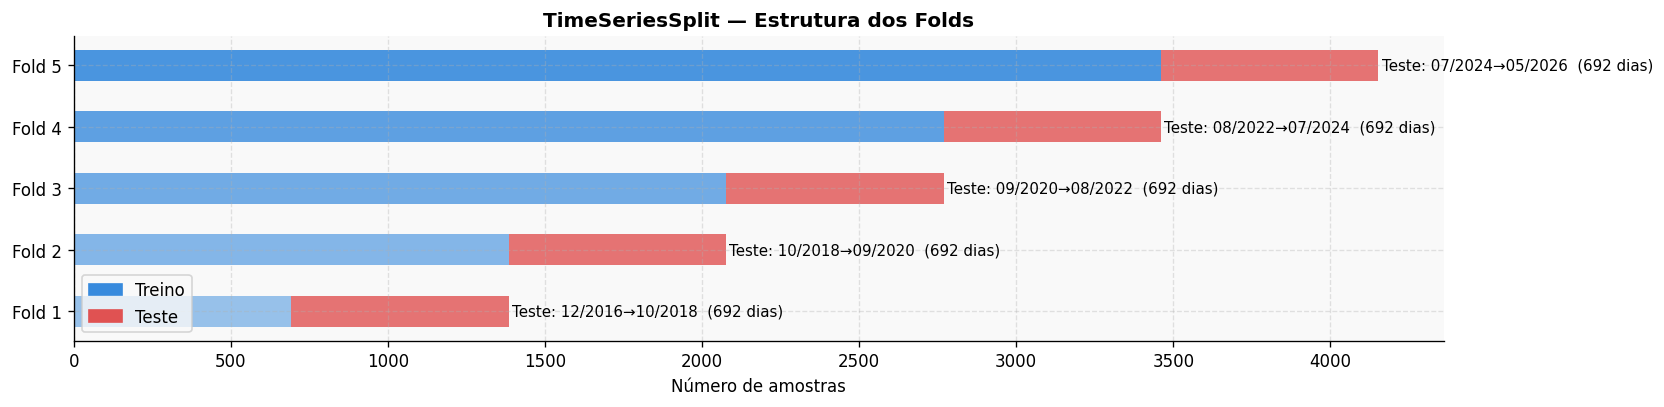

In [3]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Visualizar os folds
fig, ax = plt.subplots(figsize=(14, 3.5))
colors_fold = plt.cm.tab10(np.linspace(0, 0.5, N_SPLITS))

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    ax.barh(fold, len(train_idx), left=0,
            height=0.5, color=BLUE, alpha=0.5 + 0.1*fold)
    ax.barh(fold, len(test_idx), left=len(train_idx),
            height=0.5, color=RED, alpha=0.8)
    train_end = dates.iloc[train_idx[-1]].strftime("%m/%Y")
    test_start = dates.iloc[test_idx[0]].strftime("%m/%Y")
    test_end   = dates.iloc[test_idx[-1]].strftime("%m/%Y")
    ax.text(len(train_idx) + len(test_idx) + 10, fold,
            f"Teste: {test_start}→{test_end}  ({len(test_idx)} dias)",
            va="center", fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="Treino"),
                   Patch(color=RED,  label="Teste")], loc="lower left")
ax.set_yticks(range(N_SPLITS))
ax.set_yticklabels([f"Fold {i+1}" for i in range(N_SPLITS)])
ax.set_xlabel("Número de amostras")
ax.set_title("TimeSeriesSplit — Estrutura dos Folds", fontweight="bold")
plt.tight_layout()
plt.show()


## 2. Definição dos Modelos

In [4]:
# ── Modelos com hiperparâmetros iniciais razoáveis ────────────────────────
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            C=0.1,
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs",
            random_state=42,
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
}

if HAS_XGB:
    # XGBoost: scale_pos_weight compensa desbalanceamento
    neg_pos_ratio = (y == 0).sum() / (y == 1).sum()
    models["XGBoost"] = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=neg_pos_ratio,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )

if HAS_LGB:
    models["LightGBM"] = lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

print(f"✓ {len(models)} modelos definidos:")
for name in models:
    print(f"  - {name}")


✓ 4 modelos definidos:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM


## 3. Cross-Validation — Comparação de Modelos

In [5]:
SCORING = ["f1", "roc_auc", "average_precision", "recall", "precision"]

results_cv = {}
print("Rodando cross-validation...\n")

for name, model in models.items():
    cv_res = cross_validate(
        model, X, y,
        cv=tscv,
        scoring=SCORING,
        return_train_score=True,
        n_jobs=-1,
    )
    results_cv[name] = cv_res
    f1  = cv_res["test_f1"].mean()
    auc = cv_res["test_roc_auc"].mean()
    apr = cv_res["test_average_precision"].mean()
    rec = cv_res["test_recall"].mean()
    pre = cv_res["test_precision"].mean()
    print(f"[{name}]")
    print(f"  F1       : {f1:.3f} ± {cv_res['test_f1'].std():.3f}")
    print(f"  AUC-ROC  : {auc:.3f} ± {cv_res['test_roc_auc'].std():.3f}")
    print(f"  AUC-PR   : {apr:.3f} ± {cv_res['test_average_precision'].std():.3f}")
    print(f"  Recall   : {rec:.3f} ± {cv_res['test_recall'].std():.3f}")
    print(f"  Precision: {pre:.3f} ± {cv_res['test_precision'].std():.3f}")
    print()

print("✓ Cross-validation concluída.")


Rodando cross-validation...

[Logistic Regression]
  F1       : 0.744 ± 0.028
  AUC-ROC  : 0.914 ± 0.020
  AUC-PR   : 0.798 ± 0.021
  Recall   : 0.823 ± 0.052
  Precision: 0.684 ± 0.058

[Random Forest]
  F1       : 0.778 ± 0.020
  AUC-ROC  : 0.930 ± 0.023
  AUC-PR   : 0.850 ± 0.038
  Recall   : 0.845 ± 0.044
  Precision: 0.724 ± 0.043

[XGBoost]
  F1       : 0.767 ± 0.029
  AUC-ROC  : 0.919 ± 0.029
  AUC-PR   : 0.834 ± 0.052
  Recall   : 0.810 ± 0.055
  Precision: 0.733 ± 0.051

[LightGBM]
  F1       : 0.763 ± 0.029
  AUC-ROC  : 0.915 ± 0.029
  AUC-PR   : 0.825 ± 0.047
  Recall   : 0.793 ± 0.052
  Precision: 0.738 ± 0.042

✓ Cross-validation concluída.


In [6]:
# ── Tabela de resultados ───────────────────────────────────────────────────
rows = []
for name, cv in results_cv.items():
    rows.append({
        "Modelo"    : name,
        "F1"        : f"{cv['test_f1'].mean():.3f} ± {cv['test_f1'].std():.3f}",
        "AUC-ROC"   : f"{cv['test_roc_auc'].mean():.3f} ± {cv['test_roc_auc'].std():.3f}",
        "AUC-PR"    : f"{cv['test_average_precision'].mean():.3f} ± {cv['test_average_precision'].std():.3f}",
        "Recall"    : f"{cv['test_recall'].mean():.3f} ± {cv['test_recall'].std():.3f}",
        "Precision" : f"{cv['test_precision'].mean():.3f} ± {cv['test_precision'].std():.3f}",
    })
results_df = pd.DataFrame(rows).set_index("Modelo")
print("=== Resultados CV (TimeSeriesSplit, 5 folds) ===")
print(results_df.to_string())


=== Resultados CV (TimeSeriesSplit, 5 folds) ===
                                F1        AUC-ROC         AUC-PR         Recall      Precision
Modelo                                                                                        
Logistic Regression  0.744 ± 0.028  0.914 ± 0.020  0.798 ± 0.021  0.823 ± 0.052  0.684 ± 0.058
Random Forest        0.778 ± 0.020  0.930 ± 0.023  0.850 ± 0.038  0.845 ± 0.044  0.724 ± 0.043
XGBoost              0.767 ± 0.029  0.919 ± 0.029  0.834 ± 0.052  0.810 ± 0.055  0.733 ± 0.051
LightGBM             0.763 ± 0.029  0.915 ± 0.029  0.825 ± 0.047  0.793 ± 0.052  0.738 ± 0.042


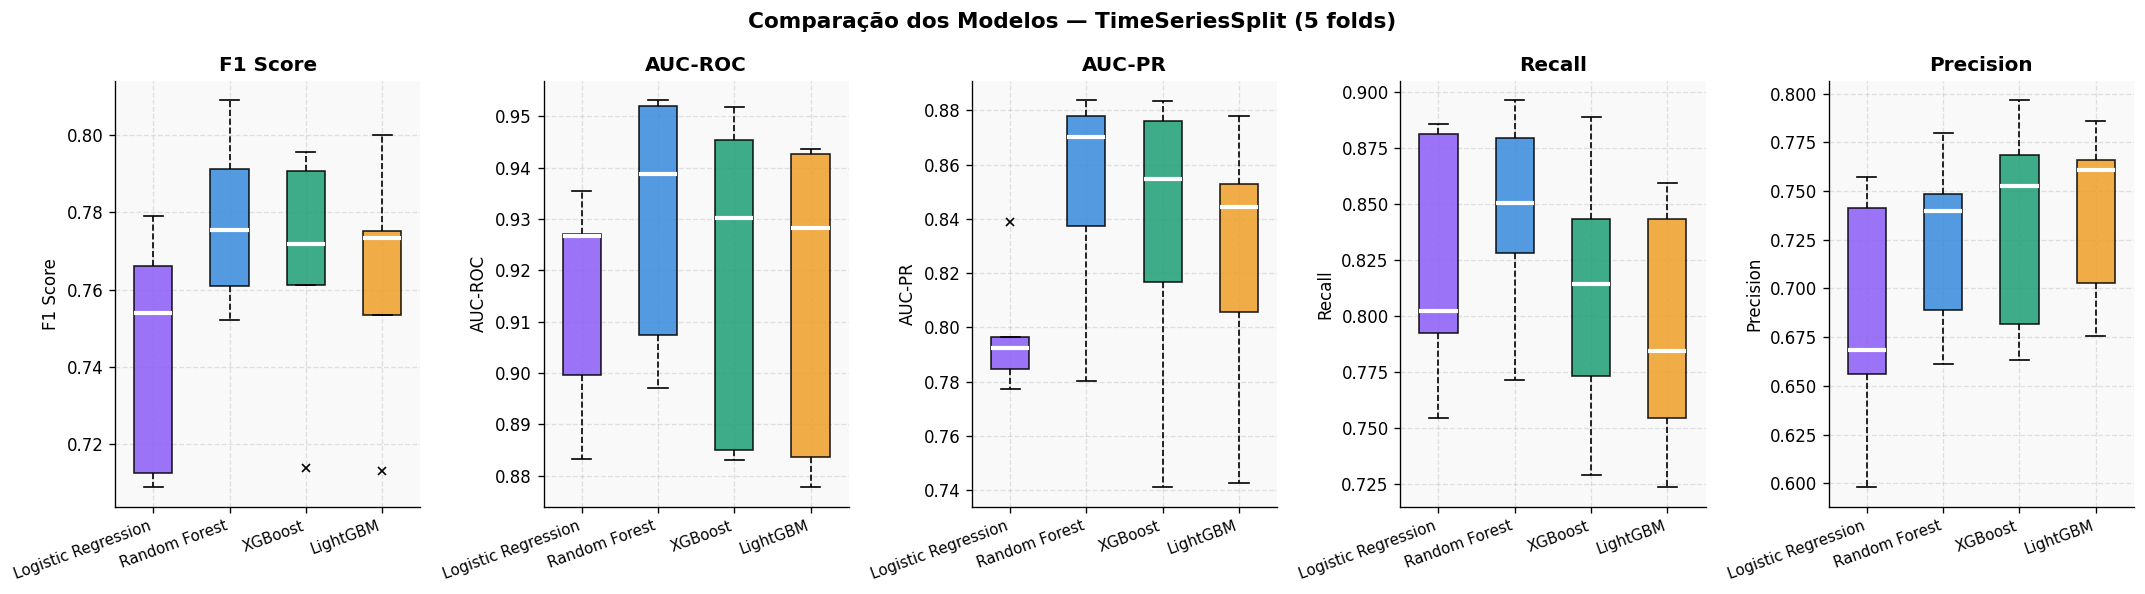

In [7]:
# ── Boxplots comparativos ──────────────────────────────────────────────────
metrics_plot = [
    ("test_f1",                  "F1 Score"),
    ("test_roc_auc",             "AUC-ROC"),
    ("test_average_precision",   "AUC-PR"),
    ("test_recall",              "Recall"),
    ("test_precision",           "Precision"),
]

fig, axes = plt.subplots(1, len(metrics_plot), figsize=(18, 5))

for ax, (metric, label) in zip(axes, metrics_plot):
    for i, (name, cv) in enumerate(results_cv.items()):
        vals = cv[metric]
        color = MODEL_COLORS.get(name, BLUE)
        bp = ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True,
                        medianprops=dict(color="white", linewidth=2.5),
                        whiskerprops=dict(linestyle="--"),
                        flierprops=dict(marker="x", markersize=5, color=color))
        bp["boxes"][0].set_facecolor(color)
        bp["boxes"][0].set_alpha(0.85)
    ax.set_xticks(range(len(results_cv)))
    ax.set_xticklabels(list(results_cv.keys()), rotation=20, ha="right", fontsize=9)
    ax.set_title(label, fontweight="bold")
    ax.set_ylabel(label)

plt.suptitle("Comparação dos Modelos — TimeSeriesSplit (5 folds)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Análise Detalhada do Melhor Modelo

In [8]:
# Selecionar melhor por AUC-PR (mais adequado para dados desbalanceados)
best_name = max(results_cv, key=lambda n: results_cv[n]["test_average_precision"].mean())
print(f"✓ Melhor modelo por AUC-PR: {best_name}")
print(f"  AUC-PR médio: {results_cv[best_name]['test_average_precision'].mean():.3f}")

# Re-treinar no penúltimo split e avaliar no último (out-of-sample)
splits = list(tscv.split(X))
train_idx, test_idx = splits[-1]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
dates_test = dates.iloc[test_idx]

best_model = models[best_name]
best_model.fit(X_train, y_train)

y_pred  = best_model.predict(X_test)
y_prob  = best_model.predict_proba(X_test)[:, 1]

print(f"\nÚltimo fold — período de teste: {dates_test.min().date()} → {dates_test.max().date()}")
print(f"Amostras: {len(y_test):,}  |  Positivos: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print()
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=["Sem alag.", "Com alag."]))


✓ Melhor modelo por AUC-PR: Random Forest
  AUC-PR médio: 0.850

Último fold — período de teste: 2024-07-06 → 2026-05-28
Amostras: 692  |  Positivos: 135 (19.5%)

=== Classification Report ===
              precision    recall  f1-score   support

   Sem alag.       0.97      0.89      0.93       557
   Com alag.       0.66      0.90      0.76       135

    accuracy                           0.89       692
   macro avg       0.82      0.89      0.84       692
weighted avg       0.91      0.89      0.90       692



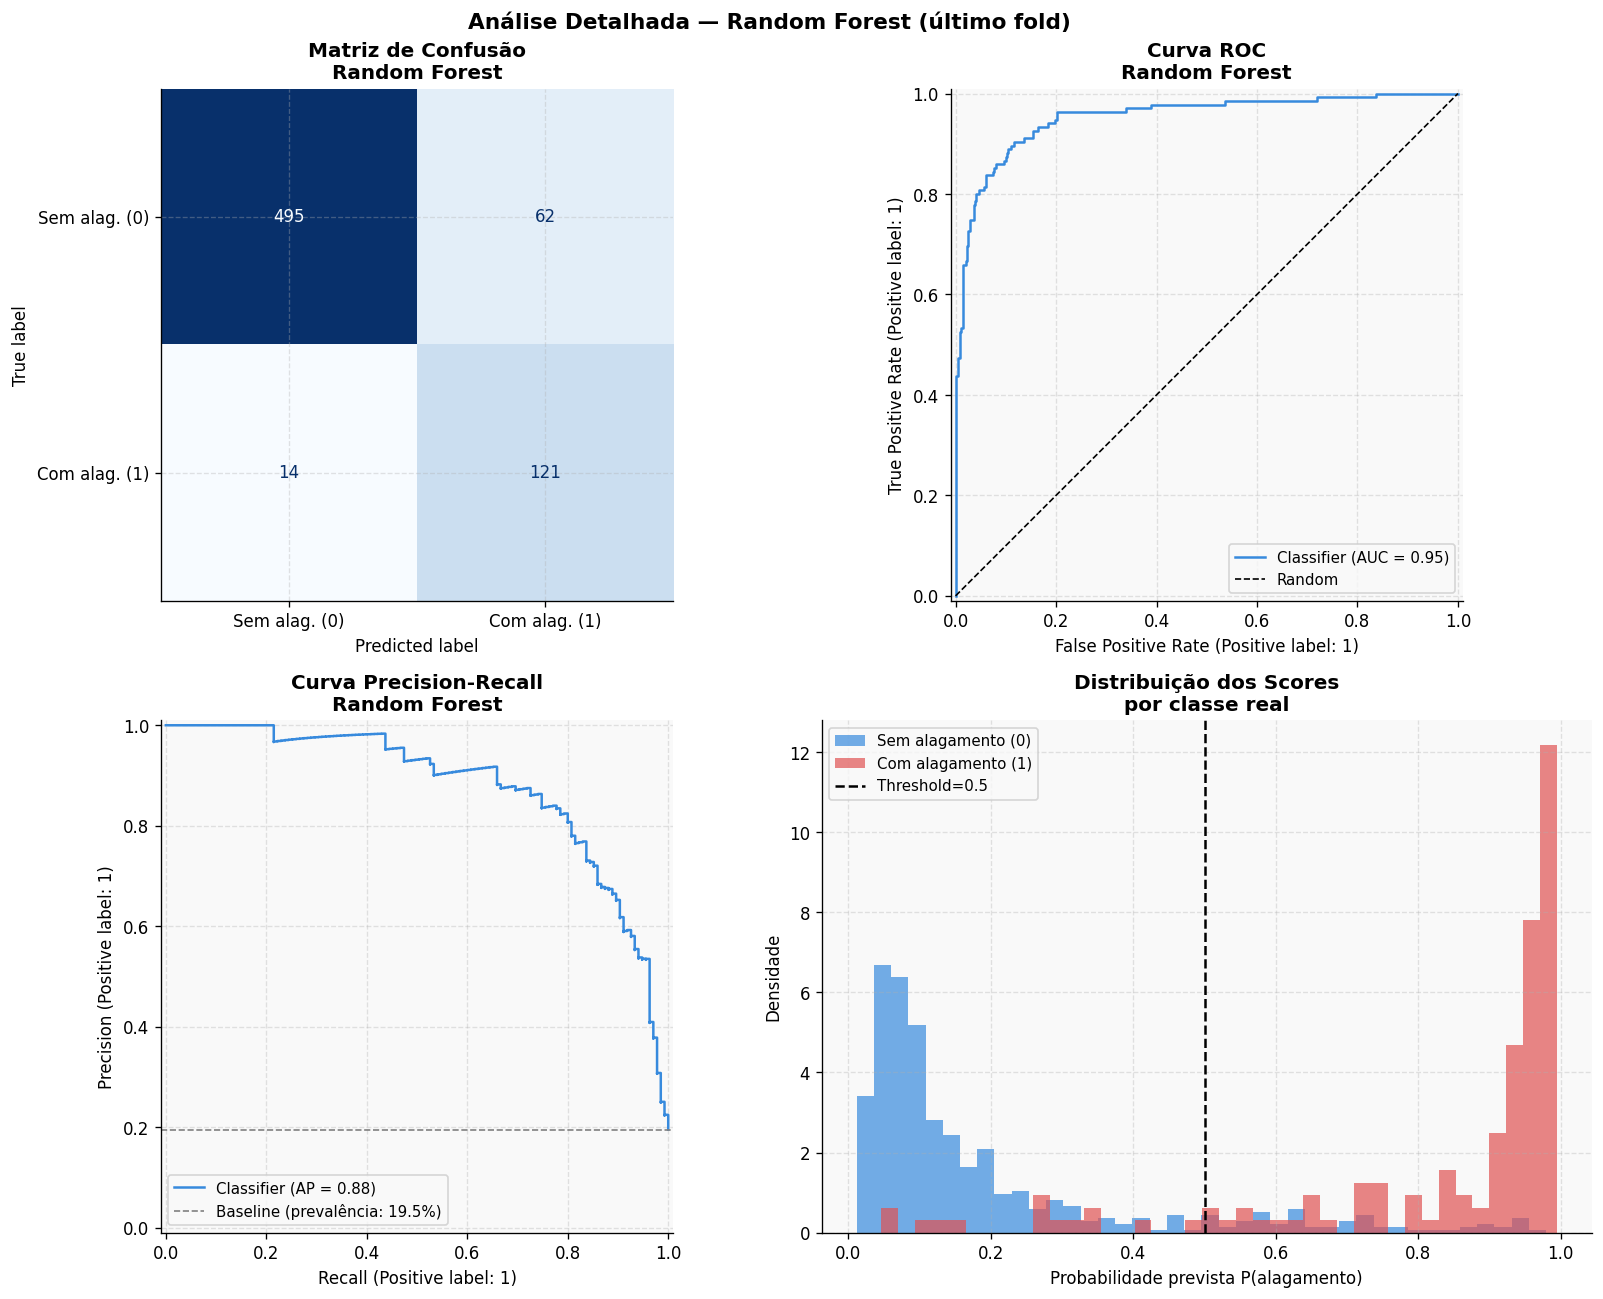

AUC-ROC : 0.9531
AUC-PR  : 0.8779


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 4.1 Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=["Sem alag. (0)", "Com alag. (1)"]
).plot(ax=axes[0, 0], cmap="Blues", colorbar=False)
axes[0, 0].set_title(f"Matriz de Confusão\n{best_name}", fontweight="bold")

# 4.2 ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0, 1],
                                  color=MODEL_COLORS.get(best_name, BLUE))
axes[0, 1].plot([0,1],[0,1],"k--",linewidth=1, label="Random")
axes[0, 1].set_title(f"Curva ROC\n{best_name}", fontweight="bold")
axes[0, 1].legend(fontsize=9)

# 4.3 Precision-Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1, 0],
                                         color=MODEL_COLORS.get(best_name, BLUE))
baseline = y_test.mean()
axes[1, 0].axhline(baseline, color="gray", linestyle="--", linewidth=1,
                    label=f"Baseline (prevalência: {baseline:.1%})")
axes[1, 0].set_title(f"Curva Precision-Recall\n{best_name}", fontweight="bold")
axes[1, 0].legend(fontsize=9)

# 4.4 Score distribution
ax = axes[1, 1]
ax.hist(y_prob[y_test==0], bins=40, color=BLUE, alpha=0.7,
        density=True, label="Sem alagamento (0)")
ax.hist(y_prob[y_test==1], bins=40, color=RED, alpha=0.7,
        density=True, label="Com alagamento (1)")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1.5, label="Threshold=0.5")
ax.set_xlabel("Probabilidade prevista P(alagamento)")
ax.set_ylabel("Densidade")
ax.set_title("Distribuição dos Scores\npor classe real", fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle(f"Análise Detalhada — {best_name} (último fold)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"AUC-ROC : {roc_auc_score(y_test, y_prob):.4f}")
print(f"AUC-PR  : {average_precision_score(y_test, y_prob):.4f}")


## 5. Threshold Tuning

O threshold padrão é 0.5, mas para alertas de alagamento **Recall é mais crítico**
(não alertar quando há alagamento é pior que alertar desnecessariamente).
Vamos encontrar o threshold ótimo para diferentes objetivos.


In [10]:
thresholds = np.linspace(0.01, 0.99, 200)
metrics_thresh = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    if y_pred_t.sum() == 0:
        continue
    metrics_thresh.append({
        "threshold" : t,
        "f1"        : f1_score(y_test, y_pred_t, zero_division=0),
        "recall"    : recall_score(y_test, y_pred_t, zero_division=0),
        "precision" : precision_score(y_test, y_pred_t, zero_division=0),
        "f2"        : (5 * precision_score(y_test, y_pred_t, zero_division=0)
                       * recall_score(y_test, y_pred_t, zero_division=0))
                      / (4 * precision_score(y_test, y_pred_t, zero_division=0)
                         + recall_score(y_test, y_pred_t, zero_division=0) + 1e-9),
    })

thresh_df = pd.DataFrame(metrics_thresh)

# Thresholds ótimos por critério
t_f1   = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]
t_f2   = thresh_df.loc[thresh_df["f2"].idxmax(), "threshold"]
t_r80  = thresh_df[thresh_df["recall"] >= 0.80]["threshold"].max()  # max thresh com recall>=80%
t_r90  = thresh_df[thresh_df["recall"] >= 0.90]["threshold"].max()  # max thresh com recall>=90%

print(f"Threshold ótimo por F1    : {t_f1:.3f}  (balanceia precisão e recall)")
print(f"Threshold ótimo por F2    : {t_f2:.3f}  (penaliza mais falso negativo)")
print(f"Threshold máx c/ Recall≥80%: {t_r80:.3f}")
print(f"Threshold máx c/ Recall≥90%: {t_r90:.3f}")
print()

# Comparar resultados nos diferentes thresholds
for t_name, t_val in [("F1 ótimo",t_f1),("F2 ótimo",t_f2),
                       ("Recall≥80%",t_r80),("Recall≥90%",t_r90),("Default",0.5)]:
    yp = (y_prob >= t_val).astype(int)
    print(f"[t={t_val:.2f} | {t_name}]  "
          f"F1={f1_score(y_test,yp,zero_division=0):.3f}  "
          f"Recall={recall_score(y_test,yp,zero_division=0):.3f}  "
          f"Precision={precision_score(y_test,yp,zero_division=0):.3f}  "
          f"Alertas/dia={yp.mean()*100:.1f}%")


Threshold ótimo por F1    : 0.729  (balanceia precisão e recall)
Threshold ótimo por F2    : 0.473  (penaliza mais falso negativo)
Threshold máx c/ Recall≥80%: 0.719
Threshold máx c/ Recall≥90%: 0.478

[t=0.73 | F1 ótimo]  F1=0.809  Recall=0.785  Precision=0.835  Alertas/dia=18.4%
[t=0.47 | F2 ótimo]  F1=0.758  Recall=0.904  Precision=0.652  Alertas/dia=27.0%
[t=0.72 | Recall≥80%]  F1=0.806  Recall=0.800  Precision=0.812  Alertas/dia=19.2%
[t=0.48 | Recall≥90%]  F1=0.758  Recall=0.904  Precision=0.652  Alertas/dia=27.0%
[t=0.50 | Default]  F1=0.761  Recall=0.896  Precision=0.661  Alertas/dia=26.4%


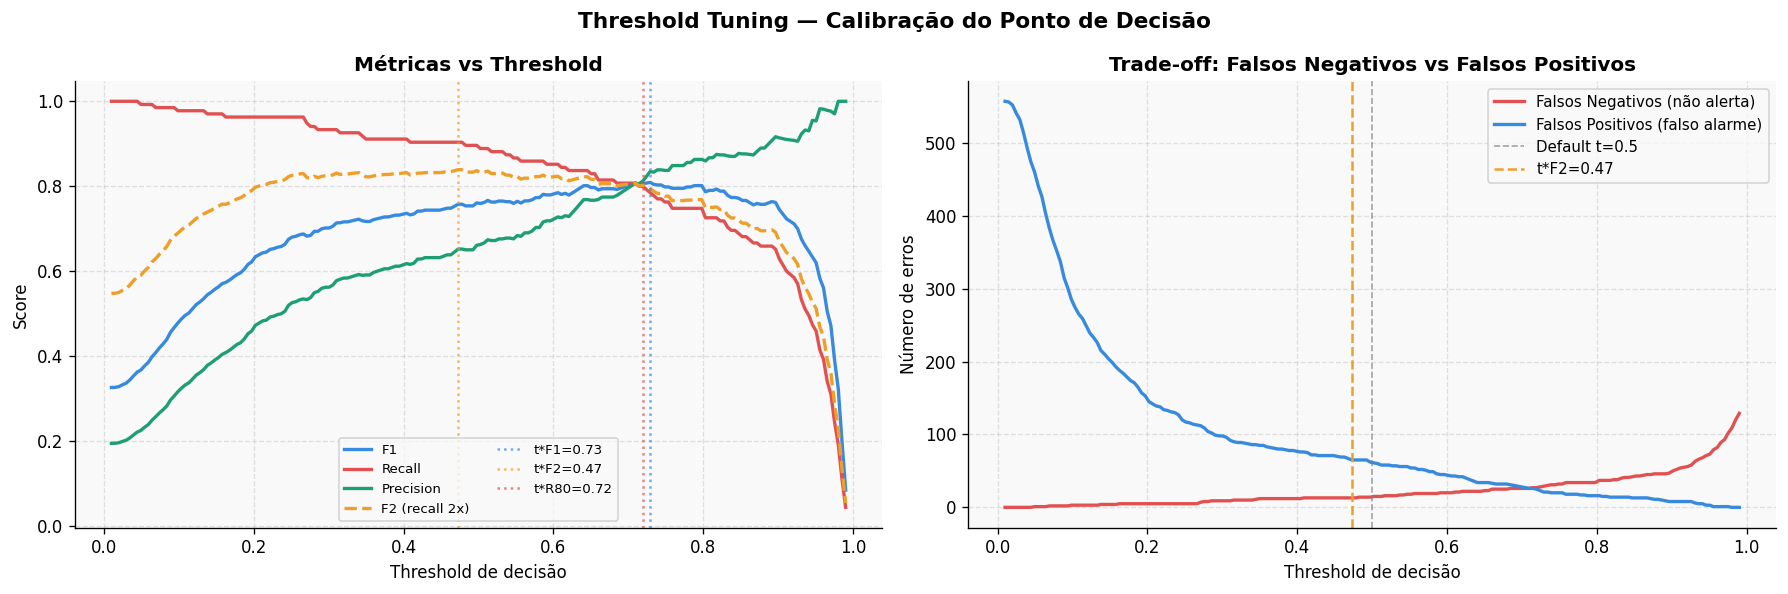

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 5.1 Curva threshold × métricas
ax = axes[0]
ax.plot(thresh_df["threshold"], thresh_df["f1"],       color=BLUE,   linewidth=2, label="F1")
ax.plot(thresh_df["threshold"], thresh_df["recall"],   color=RED,    linewidth=2, label="Recall")
ax.plot(thresh_df["threshold"], thresh_df["precision"],color=GREEN,  linewidth=2, label="Precision")
ax.plot(thresh_df["threshold"], thresh_df["f2"],       color=ORANGE, linewidth=2, linestyle="--", label="F2 (recall 2x)")
ax.axvline(t_f1,  color=BLUE,   linestyle=":", linewidth=1.5, alpha=0.7, label=f"t*F1={t_f1:.2f}")
ax.axvline(t_f2,  color=ORANGE, linestyle=":", linewidth=1.5, alpha=0.7, label=f"t*F2={t_f2:.2f}")
ax.axvline(t_r80, color=RED,    linestyle=":", linewidth=1.5, alpha=0.7, label=f"t*R80={t_r80:.2f}")
ax.set_xlabel("Threshold de decisão")
ax.set_ylabel("Score")
ax.set_title("Métricas vs Threshold", fontweight="bold")
ax.legend(fontsize=8, ncol=2)

# 5.2 Custo de erros: falsos negativos vs falsos positivos
ax = axes[1]
fn_counts, fp_counts = [], []
for t in thresh_df["threshold"]:
    yp = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, yp)
    fn_counts.append(cm[1, 0])  # alagamento não detectado
    fp_counts.append(cm[0, 1])  # falso alarme
ax.plot(thresh_df["threshold"], fn_counts, color=RED,  linewidth=2, label="Falsos Negativos (não alerta)")
ax.plot(thresh_df["threshold"], fp_counts, color=BLUE, linewidth=2, label="Falsos Positivos (falso alarme)")
ax.axvline(0.5,  color="gray", linestyle="--", linewidth=1, alpha=0.7, label="Default t=0.5")
ax.axvline(t_f2, color=ORANGE, linestyle="--", linewidth=1.5, label=f"t*F2={t_f2:.2f}")
ax.set_xlabel("Threshold de decisão")
ax.set_ylabel("Número de erros")
ax.set_title("Trade-off: Falsos Negativos vs Falsos Positivos", fontweight="bold")
ax.legend(fontsize=9)

plt.suptitle("Threshold Tuning — Calibração do Ponto de Decisão", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6. Importância das Features

Calculando Permutation Importance (pode demorar ~1 min)...


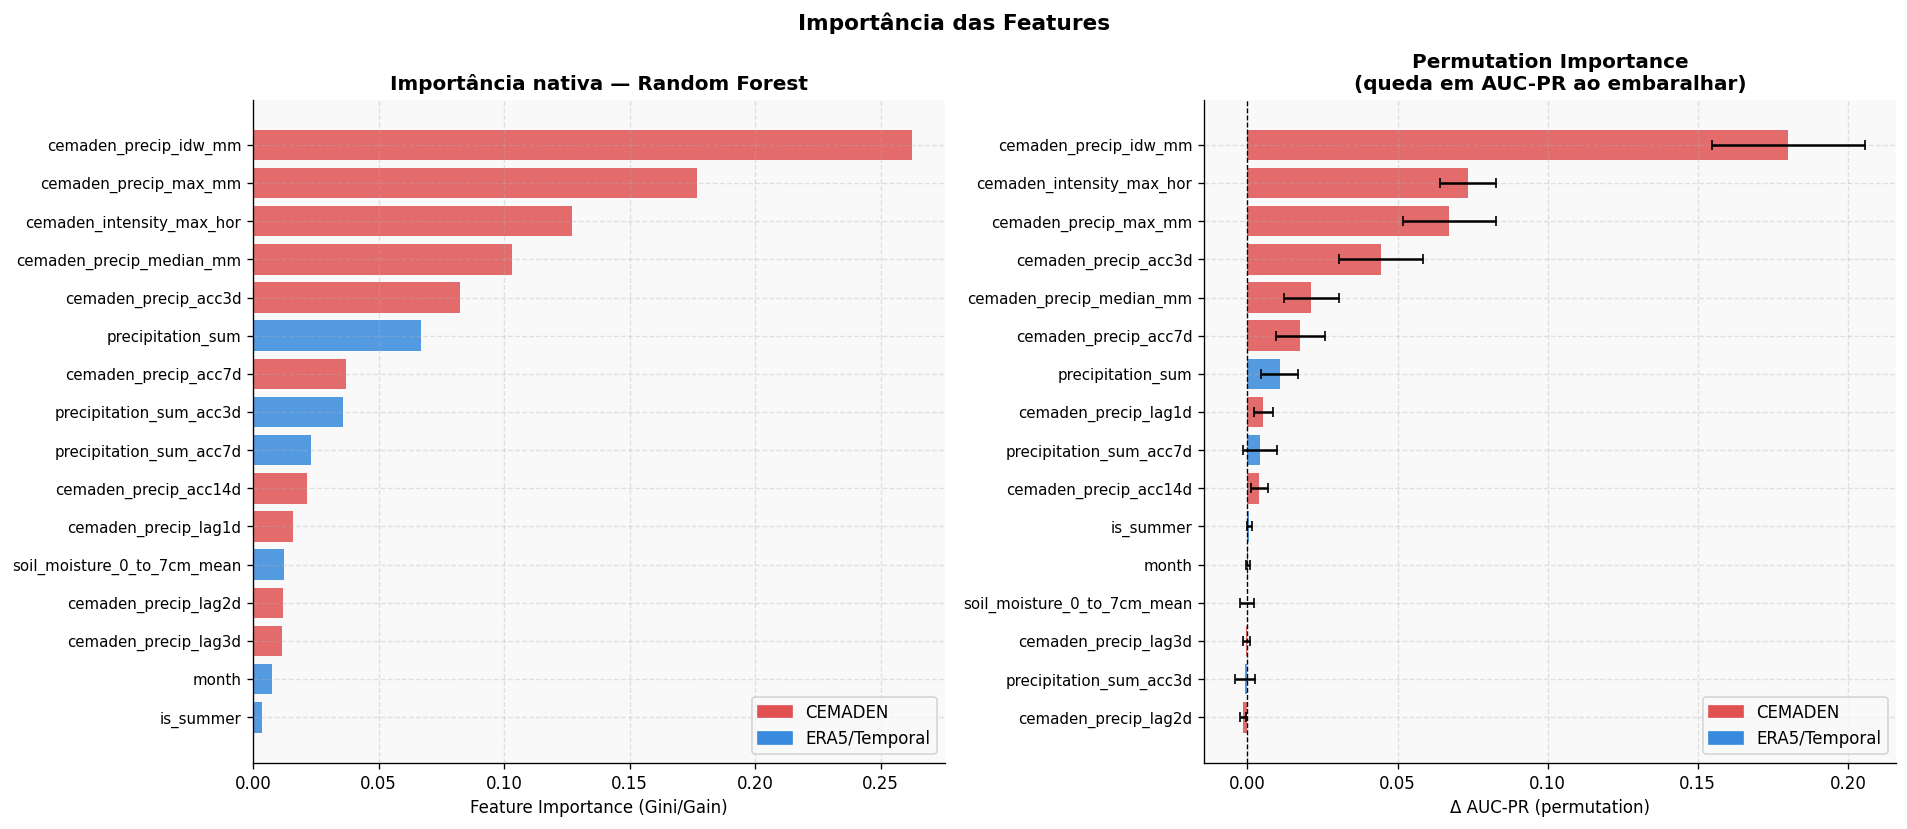


Top 10 por Permutation Importance:
                  feature  importance      std
    cemaden_precip_idw_mm    0.180171 0.025383
cemaden_intensity_max_hor    0.073488 0.009467
    cemaden_precip_max_mm    0.067297 0.015355
     cemaden_precip_acc3d    0.044448 0.013944
 cemaden_precip_median_mm    0.021270 0.009098
     cemaden_precip_acc7d    0.017654 0.008033
        precipitation_sum    0.010700 0.006078
     cemaden_precip_lag1d    0.005224 0.003136
  precipitation_sum_acc7d    0.004229 0.005736
    cemaden_precip_acc14d    0.003879 0.002821


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 6.1 Feature importance nativa do modelo
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)
    colors_imp = [RED if f.startswith("cemaden") else BLUE for f in imp.index]
    axes[0].barh(range(len(imp)), imp.values, color=colors_imp, alpha=0.85)
    axes[0].set_yticks(range(len(imp)))
    axes[0].set_yticklabels(imp.index, fontsize=9)
    axes[0].set_xlabel("Feature Importance (Gini/Gain)")
    axes[0].set_title(f"Importância nativa — {best_name}", fontweight="bold")
elif hasattr(best_model, "named_steps"):
    # Logistic Regression: coeficientes
    clf = best_model.named_steps["clf"]
    scaler = best_model.named_steps["scaler"]
    coefs = pd.Series(np.abs(clf.coef_[0]), index=ALL_FEATURES).sort_values(ascending=True)
    colors_c = [RED if f.startswith("cemaden") else BLUE for f in coefs.index]
    axes[0].barh(range(len(coefs)), coefs.values, color=colors_c, alpha=0.85)
    axes[0].set_yticks(range(len(coefs)))
    axes[0].set_yticklabels(coefs.index, fontsize=9)
    axes[0].set_xlabel("|Coeficiente| (após StandardScaler)")
    axes[0].set_title(f"Importância — {best_name}", fontweight="bold")

from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=RED, label="CEMADEN"), Patch(color=BLUE, label="ERA5/Temporal")],
               loc="lower right")

# 6.2 Permutation Importance (model-agnóstico, mais confiável)
print("Calculando Permutation Importance (pode demorar ~1 min)...")
perm = permutation_importance(best_model, X_test, y_test, n_repeats=20,
                               scoring="average_precision", random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature"   : ALL_FEATURES,
    "importance": perm.importances_mean,
    "std"       : perm.importances_std,
}).sort_values("importance", ascending=True)

colors_perm = [RED if f.startswith("cemaden") else BLUE for f in perm_df["feature"]]
axes[1].barh(range(len(perm_df)), perm_df["importance"], xerr=perm_df["std"],
             color=colors_perm, alpha=0.85, capsize=3)
axes[1].set_yticks(range(len(perm_df)))
axes[1].set_yticklabels(perm_df["feature"], fontsize=9)
axes[1].axvline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Δ AUC-PR (permutation)")
axes[1].set_title("Permutation Importance\n(queda em AUC-PR ao embaralhar)", fontweight="bold")
axes[1].legend(handles=[Patch(color=RED, label="CEMADEN"), Patch(color=BLUE, label="ERA5/Temporal")],
               loc="lower right")

plt.suptitle("Importância das Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 10 por Permutation Importance:")
print(perm_df.sort_values("importance", ascending=False).head(10).to_string(index=False))


## 7. Ablation Study — Valor Adicionado pelo CEMADEN

Comparamos três configurações de features para isolar a contribuição do CEMADEN.


In [13]:
ablation_sets = {
    "Só ERA5"         : ERA5_FEATURES + TEMPORAL_FEATURES,
    "Só CEMADEN"      : CEMADEN_FEATURES + TEMPORAL_FEATURES,
    "ERA5 + CEMADEN"  : ALL_FEATURES,
}

ablation_results = {}
best_clf_name = best_name

print("Rodando ablation study...\n")
for config_name, feat_list in ablation_sets.items():
    df_ab = df_model[feat_list + ["has_flooding"]].dropna()
    X_ab  = df_ab[feat_list]
    y_ab  = df_ab["has_flooding"]

    # Usar mesmo tipo de modelo (sem pipeline de scaling para simplificar)
    if best_clf_name == "Random Forest":
        model_ab = RandomForestClassifier(
            n_estimators=300, max_depth=10, min_samples_leaf=10,
            class_weight="balanced", random_state=42, n_jobs=-1
        )
    elif best_clf_name == "XGBoost" and HAS_XGB:
        neg_pos = (y_ab==0).sum()/(y_ab==1).sum()
        model_ab = xgb.XGBClassifier(
            n_estimators=300, max_depth=5, learning_rate=0.05,
            scale_pos_weight=neg_pos, eval_metric="logloss",
            random_state=42, n_jobs=-1
        )
    elif best_clf_name == "LightGBM" and HAS_LGB:
        model_ab = lgb.LGBMClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
        )
    else:
        model_ab = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=0.1, class_weight="balanced",
                                        max_iter=1000, random_state=42))
        ])

    cv = cross_validate(model_ab, X_ab, y_ab, cv=TimeSeriesSplit(n_splits=5),
                        scoring=["f1","roc_auc","average_precision","recall"],
                        n_jobs=-1)
    ablation_results[config_name] = cv
    print(f"[{config_name}]")
    print(f"  F1    : {cv['test_f1'].mean():.3f} ± {cv['test_f1'].std():.3f}")
    print(f"  AUC-PR: {cv['test_average_precision'].mean():.3f} ± {cv['test_average_precision'].std():.3f}")
    print(f"  Recall: {cv['test_recall'].mean():.3f} ± {cv['test_recall'].std():.3f}")
    print()


Rodando ablation study...

[Só ERA5]
  F1    : 0.640 ± 0.031
  AUC-PR: 0.653 ± 0.058
  Recall: 0.795 ± 0.057

[Só CEMADEN]
  F1    : 0.778 ± 0.023
  AUC-PR: 0.851 ± 0.033
  Recall: 0.843 ± 0.038

[ERA5 + CEMADEN]
  F1    : 0.778 ± 0.020
  AUC-PR: 0.850 ± 0.038
  Recall: 0.845 ± 0.044



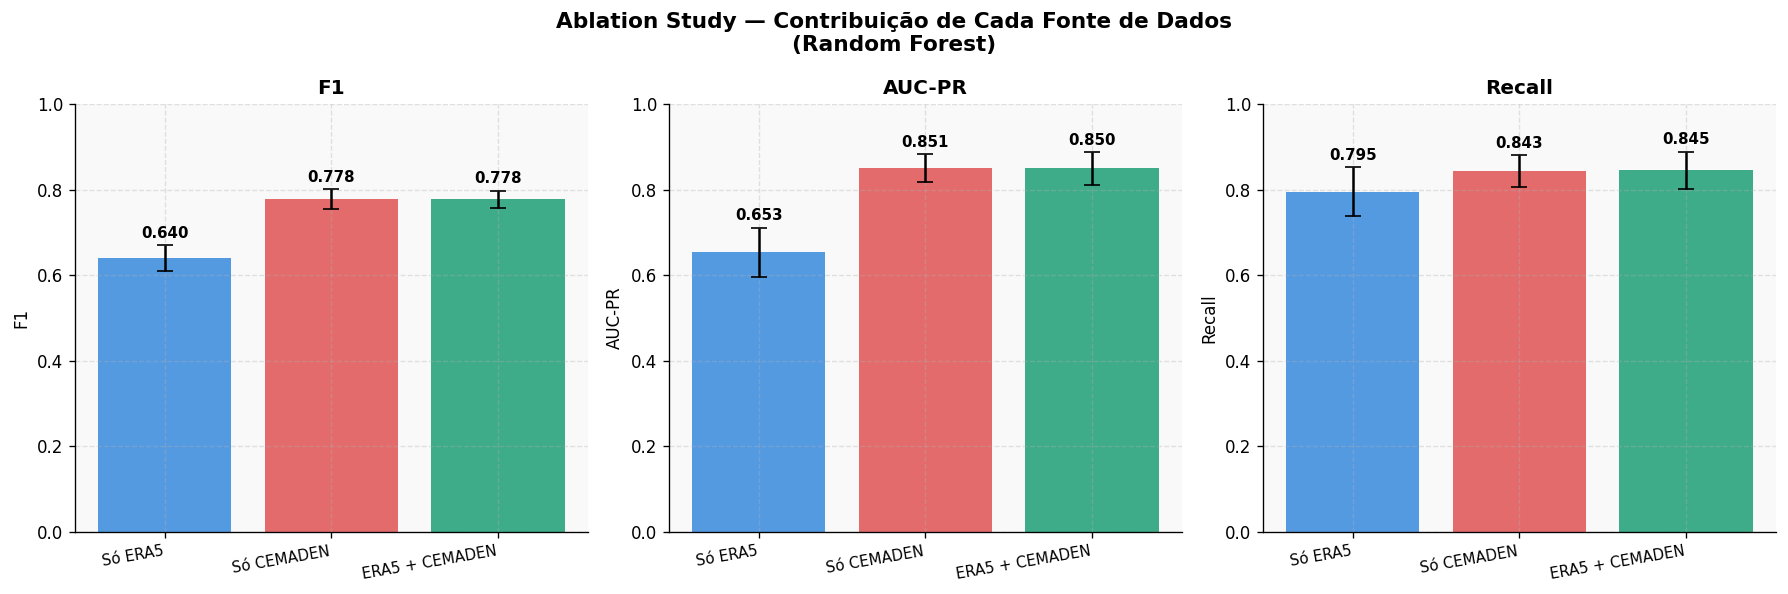


✓ Ganho ao adicionar CEMADEN ao ERA5:
  ΔF1    : +0.137
  ΔAUC-PR: +0.196


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics_ab = [("test_f1","F1"), ("test_average_precision","AUC-PR"), ("test_recall","Recall")]
colors_ab  = [BLUE, RED, GREEN]

for ax, (metric, label) in zip(axes, metrics_ab):
    names  = list(ablation_results.keys())
    means  = [ablation_results[n][metric].mean() for n in names]
    stds   = [ablation_results[n][metric].std()  for n in names]
    bars   = ax.bar(range(len(names)), means, yerr=stds,
                    color=colors_ab[:len(names)], alpha=0.85,
                    capsize=5, error_kw=dict(linewidth=1.5))
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=10, ha="right", fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(label, fontweight="bold")
    ax.set_ylim(0, min(1.0, max(means)*1.3 + 0.05))
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x()+bar.get_width()/2, m+s+0.01,
                f"{m:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle(f"Ablation Study — Contribuição de Cada Fonte de Dados\n({best_name})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Ganho do CEMADEN
gain_f1 = (ablation_results["ERA5 + CEMADEN"]["test_f1"].mean()
           - ablation_results["Só ERA5"]["test_f1"].mean())
gain_pr = (ablation_results["ERA5 + CEMADEN"]["test_average_precision"].mean()
           - ablation_results["Só ERA5"]["test_average_precision"].mean())
print(f"\n✓ Ganho ao adicionar CEMADEN ao ERA5:")
print(f"  ΔF1    : {gain_f1:+.3f}")
print(f"  ΔAUC-PR: {gain_pr:+.3f}")


## 8. Análise de Erros — Quando o Modelo Erra?

Usando threshold F2 = 0.47:
error_type
Acerto            614
Falso Positivo     65
Falso Negativo     13



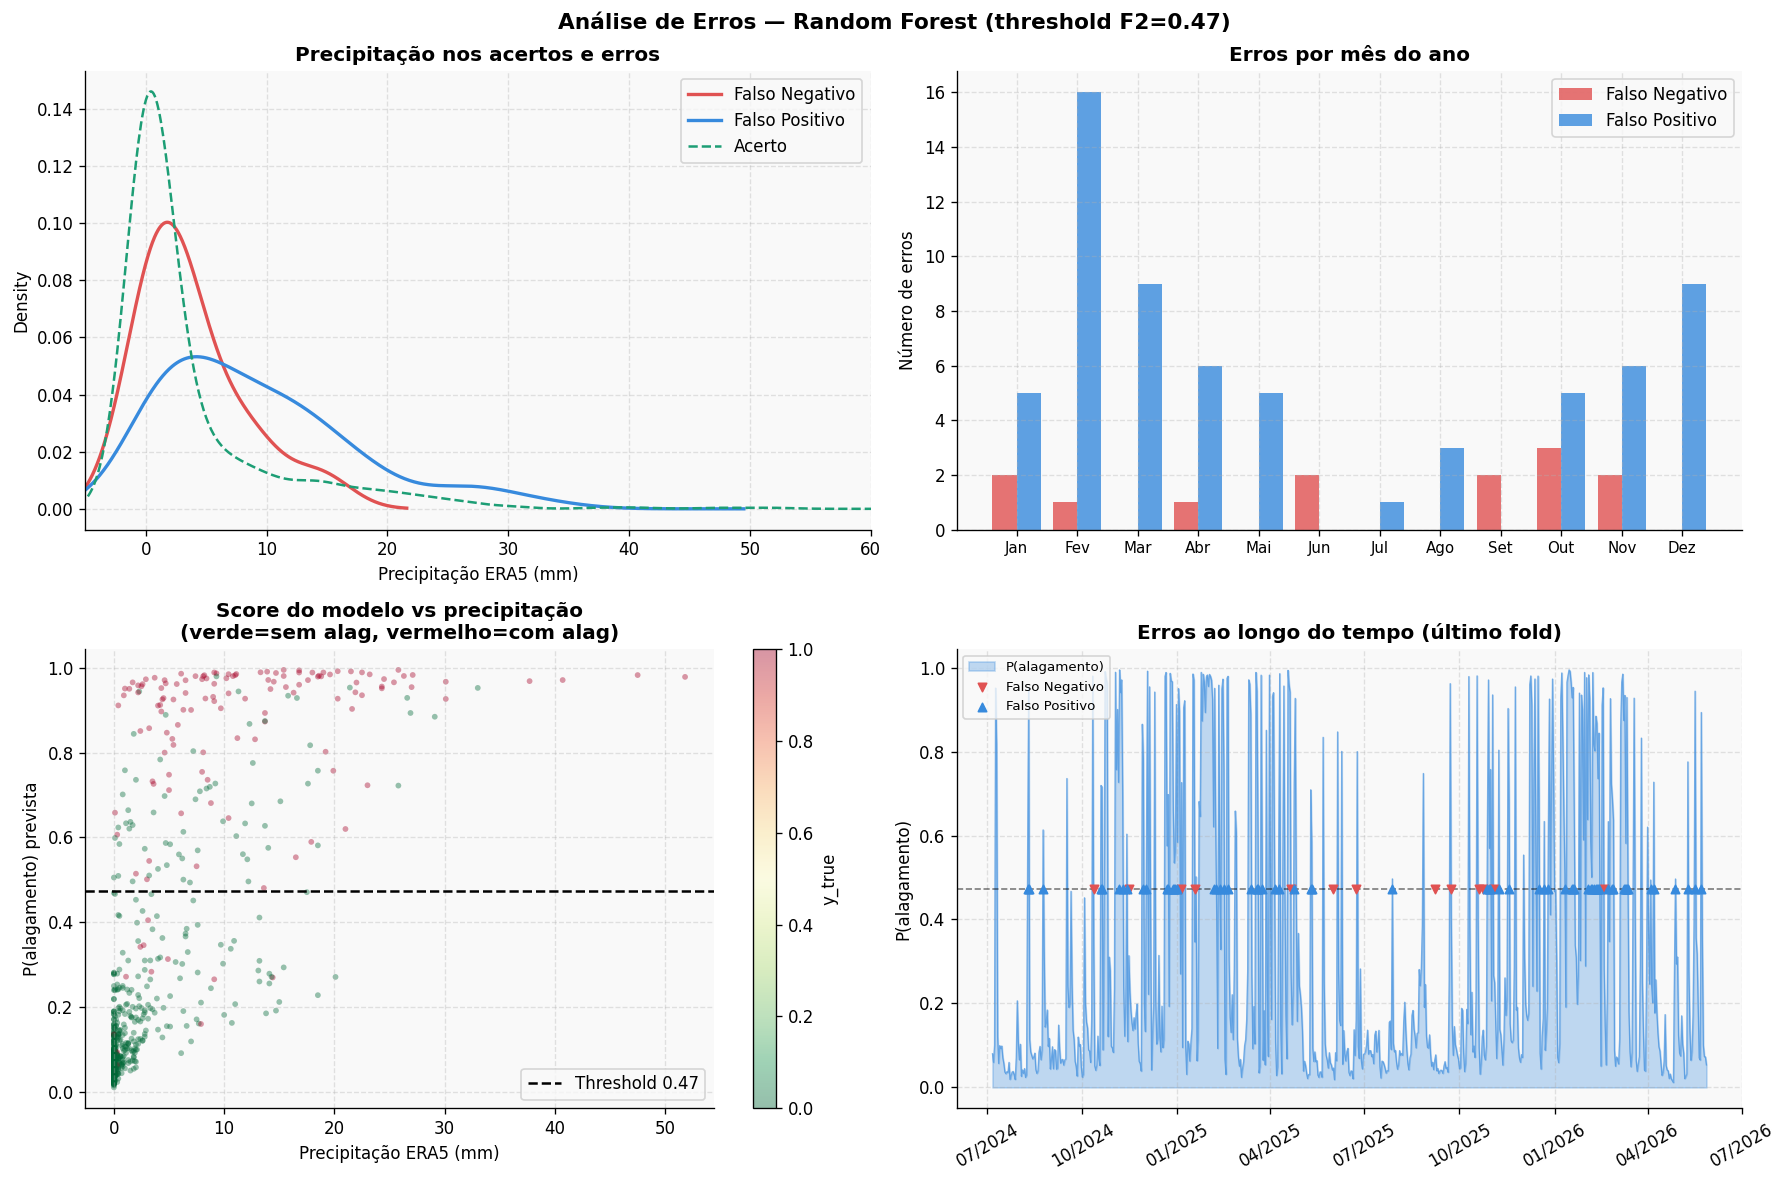


Falsos Negativos — top dias não detectados:
      date  precipitation_sum  cemaden_precip_median_mm  cemaden_precip_idw_mm  cemaden_intensity_max_hor   y_prob
2025-01-04               14.4                      0.00               0.500388                       4.33 0.270381
2025-11-03                9.1                      0.10               0.840636                       0.59 0.266142
2025-06-23                7.9                      2.17               2.818091                       1.57 0.160864
2024-11-15                4.9                      0.00               0.593297                       9.15 0.313734
2026-02-18                3.4                      0.20               1.513560                       4.33 0.283990
2025-09-23                3.1                      0.20               1.961134                       0.59 0.405275
2025-01-18                2.7                      0.40               1.144031                       3.55 0.346422
2024-10-12                2.4      

In [15]:
# Criar dataframe com predições no último fold
df_test = df_model.iloc[test_idx].copy()
df_test["y_prob"]  = y_prob
df_test["y_pred"]  = (y_prob >= t_f2).astype(int)  # usar threshold F2
df_test["y_true"]  = y_test.values
df_test["error_type"] = "Acerto"
df_test.loc[(df_test["y_true"]==1) & (df_test["y_pred"]==0), "error_type"] = "Falso Negativo"
df_test.loc[(df_test["y_true"]==0) & (df_test["y_pred"]==1), "error_type"] = "Falso Positivo"

print(f"Usando threshold F2 = {t_f2:.2f}:")
print(df_test["error_type"].value_counts().to_string())
print()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 8.1 Precipitação nos erros
ax = axes[0, 0]
error_colors = {"Falso Negativo": RED, "Falso Positivo": BLUE, "Acerto": GREEN}
for etype, group in df_test.groupby("error_type"):
    if etype != "Acerto":
        group["precipitation_sum"].plot.kde(ax=ax, label=etype,
                                             color=error_colors[etype], linewidth=2)
df_test[df_test["error_type"]=="Acerto"]["precipitation_sum"].plot.kde(
    ax=ax, label="Acerto", color=GREEN, linewidth=1.5, linestyle="--")
ax.set_xlabel("Precipitação ERA5 (mm)")
ax.set_title("Precipitação nos acertos e erros", fontweight="bold")
ax.legend(); ax.set_xlim(-5, 60)

# 8.2 Distribuição dos erros por mês
ax = axes[0, 1]
fn_by_month = df_test[df_test["error_type"]=="Falso Negativo"].groupby("month").size()
fp_by_month = df_test[df_test["error_type"]=="Falso Positivo"].groupby("month").size()
MONTH_NAMES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]
x = range(1, 13)
ax.bar([m-0.2 for m in x], [fn_by_month.get(m,0) for m in x], 0.4, color=RED, alpha=0.8, label="Falso Negativo")
ax.bar([m+0.2 for m in x], [fp_by_month.get(m,0) for m in x], 0.4, color=BLUE, alpha=0.8, label="Falso Positivo")
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
ax.set_ylabel("Número de erros")
ax.set_title("Erros por mês do ano", fontweight="bold")
ax.legend()

# 8.3 Score vs precipitação — onde o modelo tem baixa confiança
ax = axes[1, 0]
sc = ax.scatter(df_test["precipitation_sum"], df_test["y_prob"],
                c=df_test["y_true"], cmap="RdYlGn_r",
                alpha=0.4, s=12, edgecolors="none")
ax.axhline(t_f2, color="black", linestyle="--", linewidth=1.5, label=f"Threshold {t_f2:.2f}")
plt.colorbar(sc, ax=ax, label="y_true")
ax.set_xlabel("Precipitação ERA5 (mm)")
ax.set_ylabel("P(alagamento) prevista")
ax.set_title("Score do modelo vs precipitação\n(verde=sem alag, vermelho=com alag)", fontweight="bold")
ax.legend()

# 8.4 Série temporal de erros
ax = axes[1, 1]
ax.fill_between(df_test["date"], df_test["y_prob"], alpha=0.3, color=BLUE, label="P(alagamento)")
ax.plot(df_test["date"], df_test["y_prob"], color=BLUE, linewidth=0.8, alpha=0.6)
fn_dates = df_test[df_test["error_type"]=="Falso Negativo"]["date"]
fp_dates = df_test[df_test["error_type"]=="Falso Positivo"]["date"]
ax.scatter(fn_dates, [t_f2]*len(fn_dates), color=RED, zorder=5, s=25, label="Falso Negativo", marker="v")
ax.scatter(fp_dates, [t_f2]*len(fp_dates), color=BLUE, zorder=5, s=25, label="Falso Positivo", marker="^")
ax.axhline(t_f2, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_ylabel("P(alagamento)")
ax.set_title("Erros ao longo do tempo (último fold)", fontweight="bold")
ax.legend(fontsize=8)
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
plt.setp(ax.get_xticklabels(), rotation=30)

plt.suptitle(f"Análise de Erros — {best_name} (threshold F2={t_f2:.2f})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nFalsos Negativos — top dias não detectados:")
# Colunas disponíveis em df_test (derivado de df_model que contém só ALL_FEATURES + has_flooding + date)
fn_cols = ["date", "precipitation_sum", "cemaden_precip_median_mm",
           "cemaden_precip_idw_mm", "cemaden_intensity_max_hor", "y_prob"]
fn_df = (df_test[df_test["error_type"]=="Falso Negativo"][fn_cols]
         .sort_values("precipitation_sum", ascending=False)
         .head(10))
print(fn_df.to_string(index=False))

print("\nFalsos Positivos — top falsos alarmes:")
fp_cols = ["date", "precipitation_sum", "cemaden_precip_median_mm",
           "cemaden_precip_idw_mm", "y_prob"]
fp_df = (df_test[df_test["error_type"]=="Falso Positivo"][fp_cols]
         .sort_values("y_prob", ascending=False)
         .head(10))
print(fp_df.to_string(index=False))


## 9. Calibração de Probabilidades

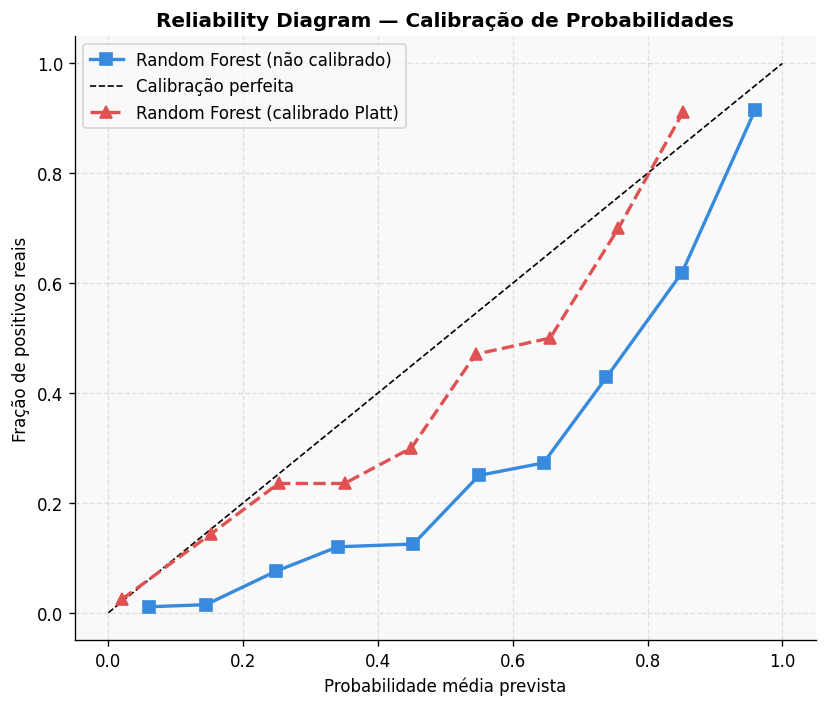

AUC-PR antes calibração: 0.8779
AUC-PR após calibração  : 0.8779


In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

# Reliability diagram
frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
ax.plot(mean_pred, frac_pos, "s-", color=MODEL_COLORS.get(best_name, BLUE),
        linewidth=2, markersize=7, label=f"{best_name} (não calibrado)")
ax.plot([0,1],[0,1], "k--", linewidth=1, label="Calibração perfeita")

# Calibrar com Platt scaling
cal_model = CalibratedClassifierCV(best_model, cv="prefit", method="sigmoid")
cal_model.fit(X_test, y_test)
y_prob_cal = cal_model.predict_proba(X_test)[:,1]
frac_pos_c, mean_pred_c = calibration_curve(y_test, y_prob_cal, n_bins=10)
ax.plot(mean_pred_c, frac_pos_c, "^--", color=RED,
        linewidth=2, markersize=7, label=f"{best_name} (calibrado Platt)")

ax.set_xlabel("Probabilidade média prevista")
ax.set_ylabel("Fração de positivos reais")
ax.set_title("Reliability Diagram — Calibração de Probabilidades", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC-PR antes calibração: {average_precision_score(y_test, y_prob):.4f}")
print(f"AUC-PR após calibração  : {average_precision_score(y_test, y_prob_cal):.4f}")


## 10. Resumo Final e Recomendações

In [17]:
print("=" * 60)
print("RESUMO DA MODELAGEM")
print("=" * 60)
print()
print("Dataset:")
print(f"  Amostras  : {len(df_model):,} dias  |  Features: {len(ALL_FEATURES)}")
print(f"  Positivos : {y.sum():,} ({y.mean()*100:.1f}%)  |  Ratio: {(1-y).mean()/y.mean():.1f}:1")
print()
print("Resultados CV (TimeSeriesSplit, 5 folds):")
for name, cv in results_cv.items():
    print(f"  {name:20s}  F1={cv['test_f1'].mean():.3f}  "
          f"AUC-PR={cv['test_average_precision'].mean():.3f}  "
          f"Recall={cv['test_recall'].mean():.3f}")
print()
print(f"Melhor modelo: {best_name}")
print(f"  Threshold F1 ótimo  : {t_f1:.2f}")
print(f"  Threshold F2 ótimo  : {t_f2:.2f}  ← recomendado para sistema de alerta")
print(f"  Threshold recall≥80%: {t_r80:.2f}")
print()
print("Ablation (CEMADEN vs ERA5):")
for cfg, cv in ablation_results.items():
    print(f"  {cfg:15s}  AUC-PR={cv['test_average_precision'].mean():.3f}")
print()
print("=" * 60)
print()
print("Próximos passos sugeridos:")
print("  1. Otimização de hiperparâmetros (Optuna)")
print("  2. Testar LSTM / modelos sequenciais")
print("  3. Análise por zona geográfica")
print("  4. Deploy como sistema de alerta com threshold F2")


RESUMO DA MODELAGEM

Dataset:
  Amostras  : 4,153 dias  |  Features: 16
  Positivos : 1,021 (24.6%)  |  Ratio: 3.1:1

Resultados CV (TimeSeriesSplit, 5 folds):
  Logistic Regression   F1=0.744  AUC-PR=0.798  Recall=0.823
  Random Forest         F1=0.778  AUC-PR=0.850  Recall=0.845
  XGBoost               F1=0.767  AUC-PR=0.834  Recall=0.810
  LightGBM              F1=0.763  AUC-PR=0.825  Recall=0.793

Melhor modelo: Random Forest
  Threshold F1 ótimo  : 0.73
  Threshold F2 ótimo  : 0.47  ← recomendado para sistema de alerta
  Threshold recall≥80%: 0.72

Ablation (CEMADEN vs ERA5):
  Só ERA5          AUC-PR=0.653
  Só CEMADEN       AUC-PR=0.851
  ERA5 + CEMADEN   AUC-PR=0.850


Próximos passos sugeridos:
  1. Otimização de hiperparâmetros (Optuna)
  2. Testar LSTM / modelos sequenciais
  3. Análise por zona geográfica
  4. Deploy como sistema de alerta com threshold F2
